# Sheet II.2 (part 2) --- HT26

# 4.

In [36]:
import numpy as np

For helper functions or variables that shouldn't need to be accessed by a user, it's common for their names to start with an underscore

In [ ]:
def _newton_iteration(x, fun, jac):
    """
    Performs a single iteration of Newton's method for root finding.
    """
    y = fun(x)
    y_prime = jac(x)
    delta = np.linalg.solve(y_prime, y)
    return x - delta.flatten()

Custom class to hold attributes from root finding

In [38]:
class RootResult:
    def __init__(self, root, iterations, success):
        self.root = root
        self.iterations = iterations
        self.success = success

In [39]:
RootResult()

TypeError: RootResult.__init__() missing 3 required positional arguments: 'root', 'iterations', and 'success'

In [ ]:
def newton(fun, jac, x0, tol=1e-8, maxiter=1000):
    """
    Newton's method to find a root of the function `fun`.
    
    Parameters:
    - fun: callable
        Function to find root of.
    - jac: callable
        The gradient or Jacobian.
    - x0: ndarray
        Initial guess.
    - tol: float, optional
        Tolerance for termination.
    - maxiter: int
        Maximum number of iterations to perform
    
    Returns:
    - res: RootResult
        The root finding result represented as a RootResult object containing the `root`, number of `iterations`, and `success` status.
    """
    x = np.array(x0, dtype=np.float64)
    
    for iteration in range(maxiter):
        if np.linalg.norm(fun(x)) < tol:
            return RootResult(x, iteration, True)
        
        x = _newton_iteration(x, fun, jac)
    
    return RootResult(x, maxiter, False)

In [ ]:
def F(X):
    (x, y) = X
    return np.array([x**2 - y - 1, x - y**2 + 1])

def J(X):
    (x, y) = X
    return np.array([[2*x, -1], [1, -2*y]])

If we use `vars`, we can see all of the attributes of the `RootResult` class as a dictionary object.

In [ ]:
# converges to [-1, 0]
print(vars(newton(F, J, [-1.2,  0.0])))

# converges to [0, -1]
print(vars(newton(F, J, [ 0.0, -1.2])))

# converges to [-1/phi, -1/phi]
print(vars(newton(F, J, [-0.6, -0.6])))

# converges to [phi, phi]
print(vars(newton(F, J, [ 1.6,  1.6])))


{'root': array([-1.00000000e+00,  1.05175516e-09]), 'iterations': 4, 'success': True}
{'root': array([ 1.05175516e-09, -1.00000000e+00]), 'iterations': 4, 'success': True}
{'root': array([-0.61803399, -0.61803399]), 'iterations': 3, 'success': True}
{'root': array([1.61803399, 1.61803399]), 'iterations': 3, 'success': True}


In python you have "Dunder methods" (https://www.geeksforgeeks.org/python/dunder-magic-methods-python/)

They change the default behaviour of the class they're in. `__init__` is an example of one, which defines how the class is initialised.

In [ ]:
print(dir(RootResult))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__']


In [ ]:
class Word:
    def __init__(self, text):
        self.text = text

In [ ]:
Word("apple") >= Word("banana")

TypeError: '>=' not supported between instances of 'Word' and 'Word'

In [ ]:
class Word:
    def __init__(self, text):
        self.text = text
    
    def __ge__(self, other):
        return ord(self.text[0]) >= ord(other.text[0])

In [ ]:
Word("apple") >= Word("banana")

False

In [ ]:
Word("apple") >= Word("anana")

True

In [ ]:
Word("apple") <= Word("banana")

True

Notice the `__str__` class. This controls how it is printed.

We used `vars` since the default behaviour is:

In [ ]:
print(newton(F, J, [-1.2,  0.0]))

In [ ]:
class RootResult:
    def __init__(self, root, iterations, success):
        self.root = root
        self.iterations = iterations
        self.success = success
    
    def __str__(self):
        root_str = np.array2string(np.asanyarray(self.root), precision=2, separator=', ', suppress_small=True)
        if self.success:
            return f"Root found: {root_str} in {self.iterations} iterations."
        else:
            return f"Failed to find root after {self.iterations} iterations."

In [ ]:
# converges to [-1, 0]
print(newton(F, J, [-1.2,  0.0]))

# converges to [0, -1]
print(newton(F, J, [ 0.0, -1.2]))

# converges to [-1/phi, -1/phi]
print(newton(F, J, [-0.6, -0.6]))

# converges to [phi, phi]
print(newton(F, J, [ 1.6,  1.6]))

Root found: [-1.,  0.] in 4 iterations.
Root found: [ 0., -1.] in 4 iterations.
Root found: [-0.62, -0.62] in 3 iterations.
Root found: [1.62, 1.62] in 3 iterations.


In [ ]:
import matplotlib.pyplot as plt

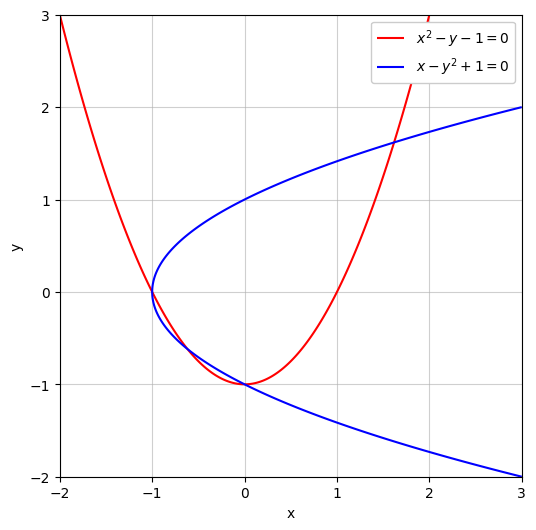

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_aspect(1.0)

x_range = np.linspace(-2, 3, 400)
y_range = np.linspace(-2, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = F([X, Y])

c1 = ax.contour(X, Y, Z[0, :, :], levels=[0], colors='red')
c2 = ax.contour(X, Y, Z[1, :, :], levels=[0], colors='blue')

h1, _ = c1.legend_elements()
h2, _ = c2.legend_elements()
ax.legend([h1[0], h2[0]], [r"$x^2 - y - 1 = 0$", r"$x - y^2 + 1 = 0$"], framealpha=1.0)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.6)

In [ ]:
res = 128
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
fractal = np.zeros((res, res))
targets = np.array([[-1, 0], [0, -1], [-0.618034, -0.618034], [1.618034, 1.618034]])

for i in range(res):
    for j in range(res):
        res_obj = newton(F, J, [X[i, j], Y[i, j]])
        if res_obj.success:
            distances = np.linalg.norm(targets - res_obj.root, axis=1)
            fractal[i, j] = np.argmin(distances)

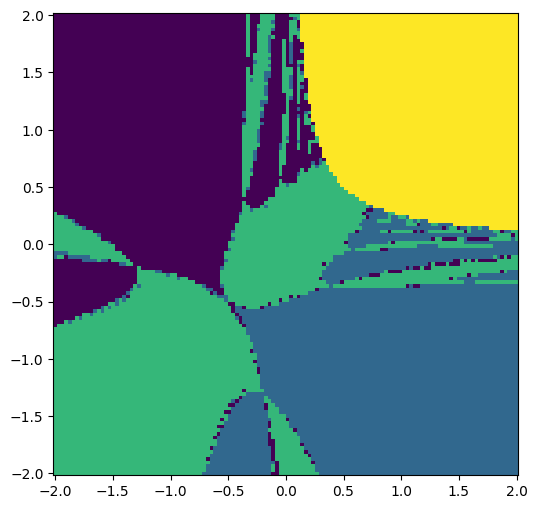

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pcolormesh(X, Y, fractal, cmap='viridis', shading='auto')

We can change the colour based on iteration

In [ ]:
fractal_iter = np.zeros((res, res))
targets = np.array([[-1, 0], [0, -1], [-0.618034, -0.618034], [1.618034, 1.618034]])

for i in range(res):
    for j in range(res):
        res_obj = newton(F, J, [X[i, j], Y[i, j]])
        if res_obj.success:
            fractal_iter[i, j] = res_obj.iterations

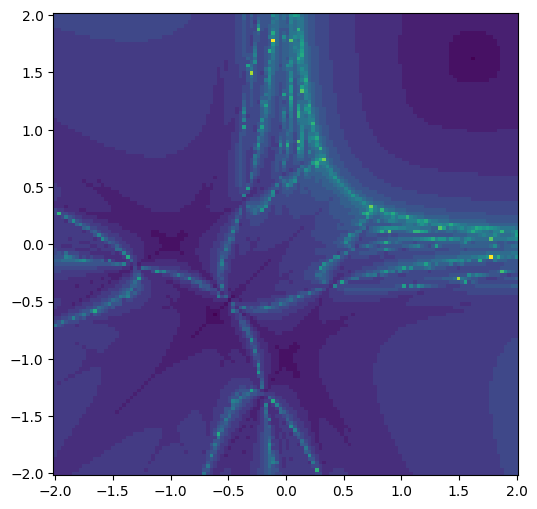

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pcolormesh(X, Y, fractal_iter, cmap='viridis', shading='auto')

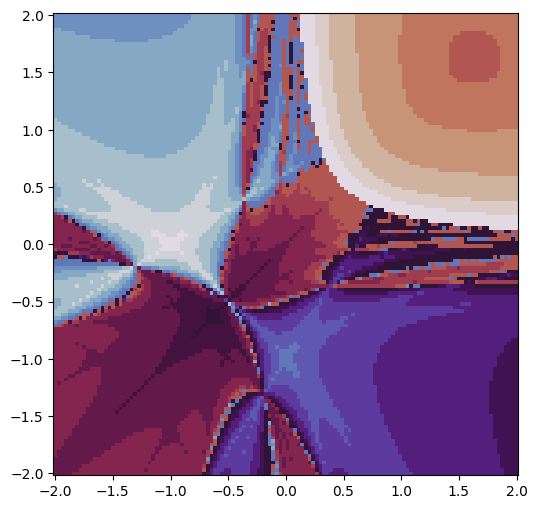

In [ ]:
fractal_both = fractal + np.clip(fractal_iter - 3, 0, 5) / 5
fractal_both = fractal_both / np.max(fractal_both)  # Normalize to [0, 1]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pcolormesh(X, Y, fractal_both, cmap='twilight', shading='auto')

# 5.

Sum of two squared terms, so $E \ge 0$. The first doesn't depend on y, so we can make that zero with $x=1$. The second term is then made zero with $y=1$ also. Hence we found the global minimum $E(1, 1) = 0$.

In [40]:
a = 1
b = 100

def E(X):
    (x, y) = X
    return (a - x)**2 + b*(y-x**2)**2

def F(X):
    (x, y) = X
    return np.array([
        -2*a - 4*b*x*(-x**2 + y) + 2*x,
        b*(-2*x**2 + 2*y)
    ])

def J(X):
    (x, y) = X
    return np.array([
        [8*b*x**2 - 4*b*(-x**2 + y) + 2, -4*b*x],
        [-4*b*x,                         2*b]
    ])


In [41]:
class OptimiseResult:
    def __init__(self, minimum, iterations, success):
        self.minimum = minimum
        self.iterations = iterations
        self.success = success

    def __str__(self):
        minimum_str = np.array2string(np.asanyarray(self.minimum), precision=2, separator=', ', suppress_small=True)
        if self.success:
            return f"Minimum found: {minimum_str} in {self.iterations} iterations."
        else:
            return f"Failed to find minimum after {self.iterations} iterations."

In [42]:
def newton_minimisation(grad, hess, x0, tol=1e-8, maxiter=1000):
    """
    Newton's method to find a minimum of the function `fun`.
    
    Parameters:
    - grad: callable
        The gradient.
    - hess: callable
        The Hessian.
    - x0: ndarray
        Initial guess.
    - tol: float, optional
        Tolerance for termination.
    - maxiter: int
        Maximum number of iterations to perform
    
    Returns:
    - res: OptimiseResult
        The minimum finding result represented as an OptimiseResult object containing the `minimum`, number of `iterations`, and `success` status.
    """
    x = np.array(x0, dtype=np.float64)
    
    for iteration in range(maxiter):
        if np.linalg.norm(grad(x)) < tol:
            return OptimiseResult(x, iteration, True)
        
        x = _newton_iteration(x, grad, hess)
    
    return OptimiseResult(x, maxiter, False)

In [43]:
print(newton_minimisation(F, J, [100, 100]))

Minimum found: [1., 1.] in 5 iterations.


In [44]:
def I500(X):
    alpha = 500
    return alpha*np.eye(2)

print(newton(F, I500, [2, 2], maxiter=100_000))

C:\Users\joe\AppData\Local\Temp\ipykernel_19700\1447956515.py:11: RuntimeWarning: overflow encountered in scalar power
  -2*a - 4*b*x*(-x**2 + y) + 2*x,
C:\Users\joe\AppData\Local\Temp\ipykernel_19700\1447956515.py:12: RuntimeWarning: overflow encountered in scalar power
  b*(-2*x**2 + 2*y)


In [45]:
def I1000(X):
    alpha = 1000
    return alpha*np.eye(2)

print(newton(F, I1000, [2, 2], maxiter=100_000))

In [46]:
def I2000(X):
    alpha = 2000
    return alpha*np.eye(2)

print(newton(F, I2000, [2, 2], maxiter=100_000))

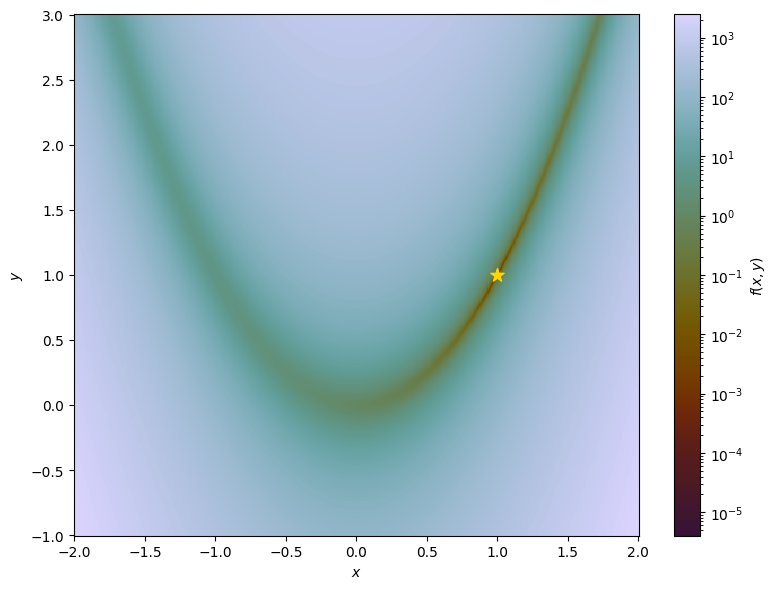

In [47]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from cmap import Colormap

cmap = Colormap("crameri:glasgow").to_mpl()

x = np.linspace(-2, 2, 500)
y = np.linspace(-1, 3, 500)
X, Y = np.meshgrid(x, y)

Z = (1 - X)**2 + 100 * (Y - X**2)**2

fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, norm=LogNorm(), cmap=cmap, shading='auto')
plt.colorbar(pcm, label='$f(x, y)$')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

Our quadratic models.
$$
    m_k^\mathsf{Q}(\mathbf{p}) =
    f(\boldsymbol\theta_k) + {\mathbf{p}}^T \nabla f(\boldsymbol\theta_k) + \frac{1}{2}\mathbf{p}^T \nabla^2 f(\boldsymbol\theta_k) \mathbf{p}.
$$

This is a very generalised way to write this, based on parameters at step $k$ denoted by $\boldsymbol\theta_k$. In this case, $\boldsymbol\theta_k$ represents the current point we are at, and hence $\nabla f(\boldsymbol\theta_k)$ represents the gradient at that point, for example.

We want to find which $\mathbf{p}$ minimises this, which we know exists if $\nabla^2 f(\boldsymbol\theta_k)$ is positive definite. Taking the derivative with respect to $\mathbf{p}$ and setting it to the zero vector:

$$\nabla_{\mathbf{p}} m_k^\mathsf{Q}(\mathbf{p}) = \nabla f(\boldsymbol\theta_k) + \nabla^2 f(\boldsymbol\theta_k) \mathbf{p} = \mathbf{0}$$

Rearranging for $\mathbf{p}$ gives the solution:

$$\nabla^2 f(\boldsymbol\theta_k) \mathbf{p} = -\nabla f(\boldsymbol\theta_k)$$

$$\mathbf{p} = -[\nabla^2 f(\boldsymbol\theta_k)]^{-1} \nabla f(\boldsymbol\theta_k)$$

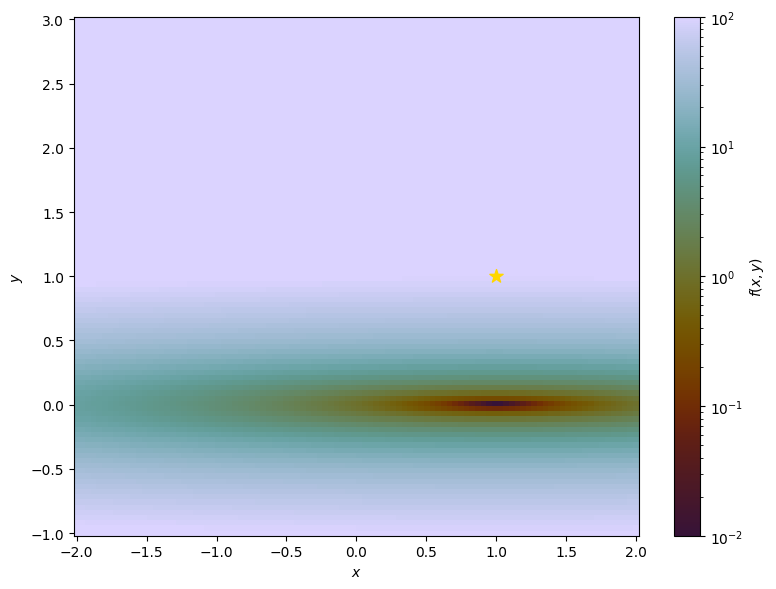

In [48]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

current_point = np.array([0.0, 0.0])

for i in range(len(x)):
    for j in range(len(y)):
        p = np.array([X[i, j], Y[i, j]]) - current_point
        
        # mk(p) = f + p^T g + 0.5 * p^T H p
        term1 = E(current_point)
        term2 = p @ F(current_point)
        term3 = 0.5 * p @ J(current_point) @ p
        Z[i, j] = term1 + term2 + term3


fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, norm=LogNorm(vmin=1e-2, vmax=1e2), cmap=cmap, shading='auto')
plt.colorbar(pcm, label='$f(x, y)$')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

This uses the quadratic model
$$
    m_k^\mathsf{Q}(\mathbf{p}) =
    f(\boldsymbol\theta_k) + {\mathbf{p}}^T \nabla f(\boldsymbol\theta_k) + \frac{\alpha}{2}\mathbf{p}^T \boldsymbol{I} \mathbf{p}
$$

with solution

$$\mathbf{p} = -\dfrac{1}{\alpha} \nabla f(\boldsymbol\theta_k)$$

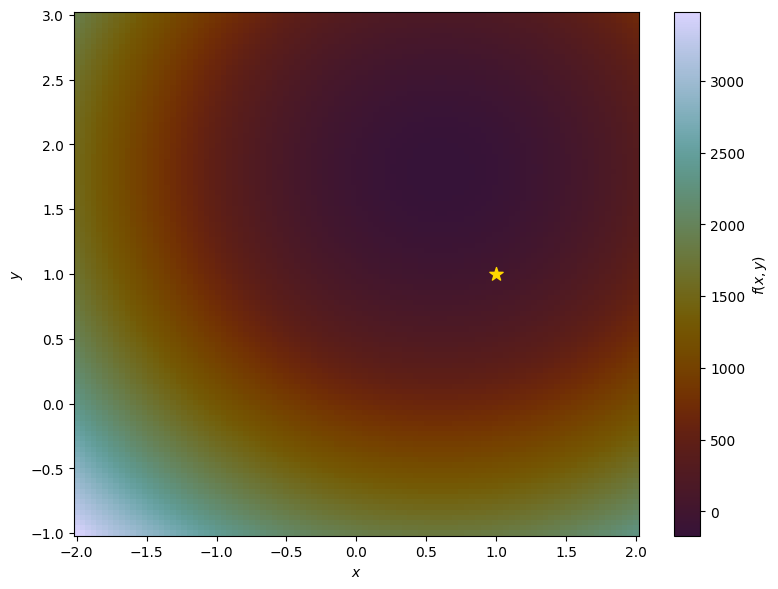

In [58]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

current_point = np.array([1.5, 1.5])

for i in range(len(x)):
    for j in range(len(y)):
        p = np.array([X[i, j], Y[i, j]])  - current_point
        
        # mk(p) = f + p^T g + 0.5 * p^T H p
        term1 = E(current_point)
        term2 = p @ F(current_point)
        term3 = 0.5 * p @ I500(current_point) @ p
        Z[i, j] = term1 + term2 + term3


fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, cmap=cmap, shading='auto')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.colorbar(pcm, label='$f(x, y)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

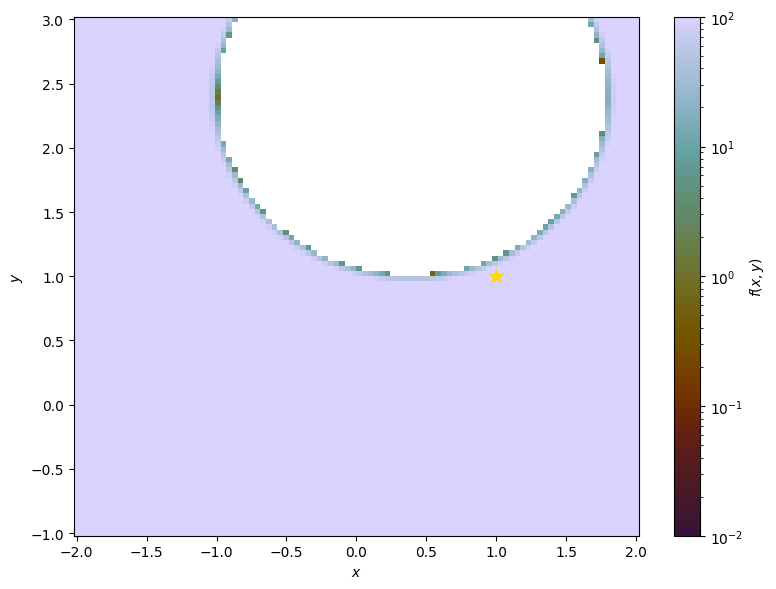

In [108]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

current_point = np.array([2.0, 2.0])

for i in range(len(x)):
    for j in range(len(y)):
        p = np.array([X[i, j], Y[i, j]]) - current_point
        
        # mk(p) = f + p^T g + 0.5 * p^T H p
        term1 = E(current_point)
        term2 = p @ F(current_point)
        term3 = 0.5 * p @ I1000(current_point) @ p
        Z[i, j] = term1 + term2 + term3


fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, norm=LogNorm(vmin=1e-2, vmax=1e2), cmap=cmap, shading='auto')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.colorbar(pcm, label='$f(x, y)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

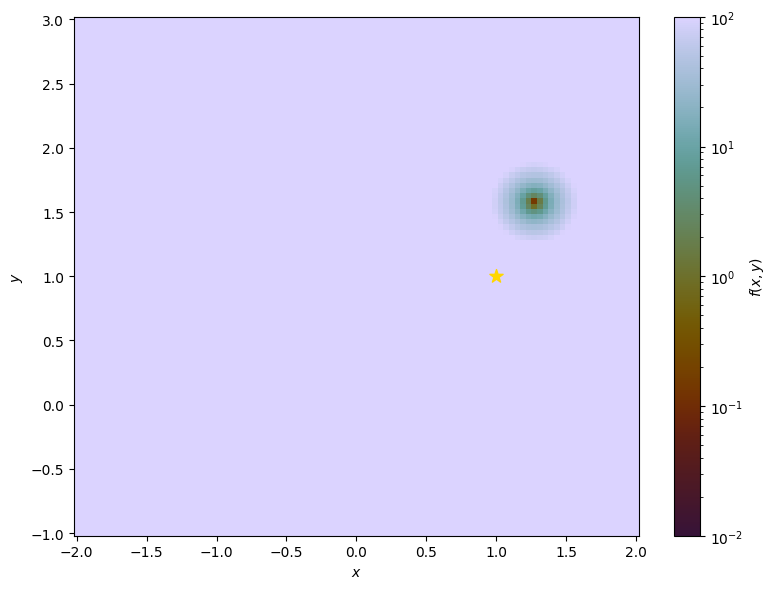

In [60]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

current_point = np.array([2.0, 2.0]) - current_point

for i in range(len(x)):
    for j in range(len(y)):
        p = np.array([X[i, j], Y[i, j]]) - current_point
        
        # mk(p) = f + p^T g + 0.5 * p^T H p
        term1 = E(current_point)
        term2 = p @ F(current_point)
        term3 = 0.5 * p @ I2000(current_point) @ p
        Z[i, j] = term1 + term2 + term3


fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, norm=LogNorm(vmin=1e-2, vmax=1e2), cmap=cmap, shading='auto')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.colorbar(pcm, label='$f(x, y)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

Second iteration using Hessian, going from (1, 0) now

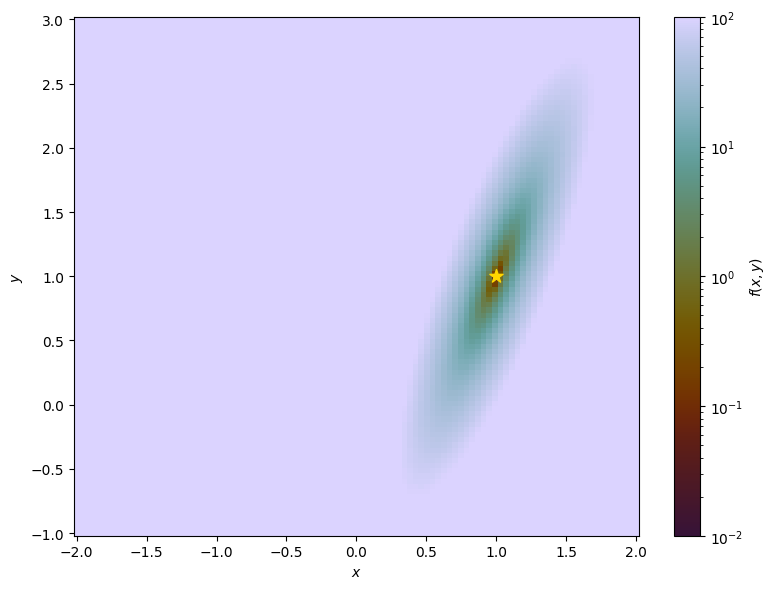

In [ ]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

current_point = np.array([1.0, 0.0])

for i in range(len(x)):
    for j in range(len(y)):
        p = np.array([X[i, j], Y[i, j]]) - current_point
        
        # mk(p) = f + p^T g + 0.5 * p^T H p
        term1 = E(current_point)
        term2 = p @ F(current_point)
        term3 = 0.5 * p @ J(current_point) @ p
        Z[i, j] = term1 + term2 + term3


fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(X, Y, Z, norm=LogNorm(vmin=1e-2, vmax=1e2), cmap=cmap, shading='auto')
plt.colorbar(pcm, label='$f(x, y)$')
plt.scatter([1], [1], color='gold', marker='*', s=100, label='Minimum')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.tight_layout()
plt.show()

In [64]:
import numba as nb

In [91]:
def fun(x):
    for _ in range(10_000_000):
        x = x + 1
    return x

In [92]:
import time
start_time = time.time()
fun(0)
print(f"Execution time: {time.time() - start_time:.4f} seconds")

Execution time: 1.0526 seconds


In [107]:
@nb.njit
def funfast(x):
    for _ in range(10_000_000):
        x = x + 1
    return x

In [105]:
start_time = time.time()
print(funfast(0))
print(f"Execution time: {time.time() - start_time:.9f} seconds")

10000000
Execution time: 0.000000000 seconds
